In [14]:
import re
from typing import List
from gensim.models import Word2Vec
# from gensim.models import Word2Vec


In [15]:
train_text = """ I love Deep Learning. 
And I love NLP, with or without deep learning. 
In general I love AI, but I don't like A.B.C."""

def tokenize(text: str, pattern: str = None) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)
    return tokens
train_tokens = tokenize(train_text)


In [18]:
# instantiate the model
model = Word2Vec(
    vector_size=5,            # embedding dimension (d)
    window=4,                  # context windon
    min_count=1,               # include words with freq >= 1 (important for small corpus)
    sg=1,                      # 1 = skip-gram, 0 = CBOW
    epochs=2000,
    seed=42,
    workers=4,
    negative=6,
)

# build vocabulary
model.build_vocab([train_tokens])  # Word2Vec expects a list of lists
print(
    model.wv.key_to_index
)

# train the model
model.train(
    corpus_iterable=[train_tokens],
    total_examples=len(train_tokens),
    epochs=200
)

# alternative way to train the model
# model.train(
#     sentences=[train_tokens],
#     total_examples=len([train_tokens]),
#     epochs=200
# )
print(
    f"embeding dimension: {model.wv.vectors.shape}"
)

{'I': 0, 'love': 1, '.': 2, 'A.B.C.': 3, 'like': 4, "don't": 5, 'but': 6, 'AI': 7, 'general': 8, 'In': 9, 'learning': 10, 'deep': 11, 'without': 12, 'or': 13, 'with': 14, 'NLP': 15, 'And': 16, 'Learning': 17, 'Deep': 18}
embeding dimension: (19, 5)


In [26]:
model.wv["love"]

array([0.6981044 , 0.07387147, 0.38095242, 0.18217646, 0.46002933],
      dtype=float32)

In [24]:
model.wv.vectors   # shape (vocab_size, embedding_dim)

array([[ 0.4425662 ,  0.35835934,  0.38762248,  0.30341855,  0.65687245],
       [ 0.6981044 ,  0.07387147,  0.38095242,  0.18217646,  0.46002933],
       [ 0.47758225,  0.3786307 ,  0.34054515,  0.35318246,  0.61067146],
       [ 0.48739308,  0.16168499,  0.05600535,  0.33601406,  0.40735495],
       [ 0.34354255,  0.09196817,  0.06063605,  0.35193557,  0.4946027 ],
       [ 0.48929533,  0.14889741,  0.37308928,  0.24604589,  0.47482148],
       [ 0.42056087,  0.07238551,  0.07245814,  0.2571626 ,  0.65894634],
       [ 0.2665821 ,  0.33146662,  0.3727939 ,  0.14792104,  0.5565547 ],
       [ 0.17701514,  0.24505389,  0.25905815,  0.11309266,  0.20028943],
       [ 0.7275826 ,  0.19992326,  0.4487143 ,  0.35875982,  0.72340477],
       [ 0.55351746,  0.05559079,  0.18253127,  0.22645178,  0.49109614],
       [ 0.26831442,  0.19858481,  0.10229388,  0.33879754,  0.5818018 ],
       [ 0.4761014 ,  0.22814313,  0.1149632 ,  0.35740072,  0.32156423],
       [ 0.37087405,  0.34131184,  0.1

In [7]:
list(model.wv.key_to_index.keys())


['I',
 'love',
 '.',
 'A.B.C.',
 'like',
 "don't",
 'but',
 'AI',
 'general',
 'In',
 'learning',
 'deep',
 'without',
 'or',
 'with',
 'NLP',
 'And',
 'Learning',
 'Deep']

In [8]:
print(f" Cosine-sim(love, AI): {model.wv.similarity("love", "AI"):.3f}")

print(f" Cosine-sim(love, A.B.C.): {model.wv.similarity("love", "A.B.C."):.3f}")

print(f" Cosine-sim(like, A.B.C.): {model.wv.similarity("like", "A.B.C."):.3f}")



 Cosine-sim(love, AI): 0.838
 Cosine-sim(love, A.B.C.): 0.896
 Cosine-sim(like, A.B.C.): 0.969


In [13]:
model.wv[words]

array([[ 0.4425662 ,  0.35835934,  0.38762248,  0.30341855,  0.65687245],
       [ 0.6981044 ,  0.07387147,  0.38095242,  0.18217646,  0.46002933],
       [ 0.47758225,  0.3786307 ,  0.34054515,  0.35318246,  0.61067146],
       [ 0.48739308,  0.16168499,  0.05600535,  0.33601406,  0.40735495],
       [ 0.34354255,  0.09196817,  0.06063605,  0.35193557,  0.4946027 ],
       [ 0.48929533,  0.14889741,  0.37308928,  0.24604589,  0.47482148],
       [ 0.42056087,  0.07238551,  0.07245814,  0.2571626 ,  0.65894634],
       [ 0.2665821 ,  0.33146662,  0.3727939 ,  0.14792104,  0.5565547 ],
       [ 0.17701514,  0.24505389,  0.25905815,  0.11309266,  0.20028943],
       [ 0.7275826 ,  0.19992326,  0.4487143 ,  0.35875982,  0.72340477],
       [ 0.55351746,  0.05559079,  0.18253127,  0.22645178,  0.49109614],
       [ 0.26831442,  0.19858481,  0.10229388,  0.33879754,  0.5818018 ],
       [ 0.4761014 ,  0.22814313,  0.1149632 ,  0.35740072,  0.32156423],
       [ 0.37087405,  0.34131184,  0.1

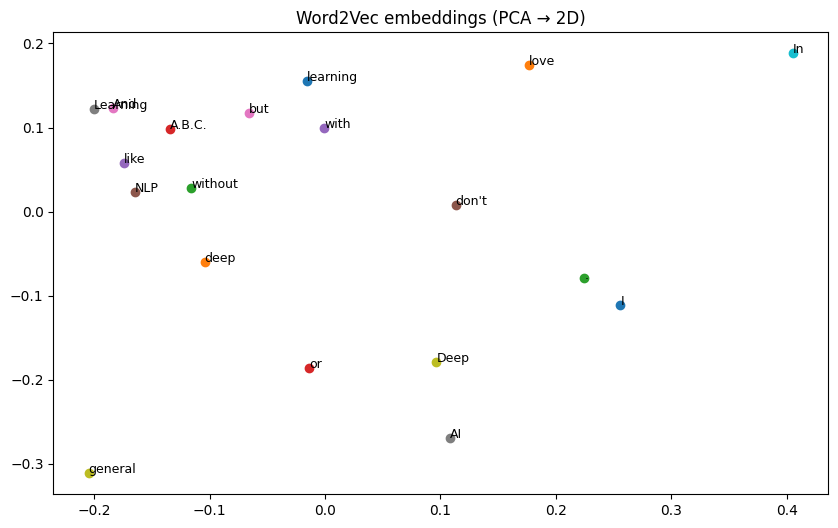

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.key_to_index.keys())
vectors = model.wv[words]          # shape: (vocab, 50)

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(coords[i, 0], coords[i, 1])
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title("Word2Vec embeddings (PCA → 2D)")
plt.show()